# Análise Exploratória 1: Caracterização Temporal e Distribuições

Este notebook realiza análise exploratória inicial do dataset completo, focando em padrões temporais e distribuições estatísticas.

**Análises**: Evolução temporal (vídeos, comentários, canais, usuários) → Distribuições (comentários por vídeo/canal/usuário, tamanho de comentários)

---
## 1. Carregamento de Dados

Carrega o dataset completo (`df_full.csv`) que combina informações de vídeos, comentários e tópicos. Converte colunas de data para tipo datetime.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams as nltk_ngrams
import re
from scipy import stats
from scipy.stats import zscore
from collections import Counter

stopwords_pt = set(stopwords.words('portuguese'))

In [2]:
df = pd.read_csv('resumos/df_full.csv')
df['published_at'] = pd.to_datetime(df['published_at'])
df['updated_at'] = pd.to_datetime(df['updated_at'])
df.head()

,video_id,tema_principal,motivo_de_uso,esteroides_anabolizantes_mencionados,sintomas_e_efeitos_mencionados,menciona_fontes_cientificas,tipo_de_conteudo,publico_alvo,autoridade_percebida,resumo,...,like_count,is_reply,parent_id,channel_id,language,language_langdetect,probs_Autorrelato,pred_Autorrelato,probs_Sintomas_Efeitos_Colaterais,pred_Sintomas_Efeitos_Colaterais
0,--KaHgAv81Y,sono e testosterona,Educativo/Não Especificado,['testosterona'],"['ansiedade', 'libido baixa', 'testosterona ba...",False,Explicação Técnica,Público Geral,Desconhecido,o vídeo enfatiza que o sono não serve apenas p...,...,0,0,root,UCrRO3ZQGIHnYHZ7rC1Vqv4Q,pt,rob_pt,5.960465e-07,0,0.000471,0
1,--KaHgAv81Y,sono e testosterona,Educativo/Não Especificado,['testosterona'],"['ansiedade', 'libido baixa', 'testosterona ba...",False,Explicação Técnica,Público Geral,Desconhecido,o vídeo enfatiza que o sono não serve apenas p...,...,0,0,root,UCrRO3ZQGIHnYHZ7rC1Vqv4Q,pt,rob_pt,4.553223e-02,0,0.428955,0
2,--KaHgAv81Y,sono e testosterona,Educativo/Não Especificado,['testosterona'],"['ansiedade', 'libido baixa', 'testosterona ba...",False,Explicação Técnica,Público Geral,Desconhecido,o vídeo enfatiza que o sono não serve apenas p...,...,1,0,root,UCrRO3ZQGIHnYHZ7rC1Vqv4Q,pt,rob_pt,6.512451e-02,0,0.636230,0
3,--KaHgAv81Y,sono e testosterona,Educativo/Não Especificado,['testosterona'],"['ansiedade', 'libido baixa', 'testosterona ba...",False,Explicação Técnica,Público Geral,Desconhecido,o vídeo enfatiza que o sono não serve apenas p...,...,1,0,root,UCrRO3ZQGIHnYHZ7rC1Vqv4Q,pt,rob_pt,9.039307e-02,0,0.834473,1
4,--KaHgAv81Y,sono e testosterona,Educativo/Não Especificado,['testosterona'],"['ansiedade', 'libido baixa', 'testosterona ba...",False,Explicação Técnica,Público Geral,Desconhecido,o vídeo enfatiza que o sono não serve apenas p...,...,1,0,root,UCrRO3ZQGIHnYHZ7rC1Vqv4Q,pt,rob_pt,1.789093e-03,0,0.376221,0


In [3]:
df['channel_id'].nunique(), df['author_channel_id'].nunique(), df['video_id'].nunique(), df['comment_id'].nunique()

(1323, 205269, 6104, 478397)

In [4]:
df.shape

(478397, 32)

---
## 2. Análise Temporal de Comentários e Usuários

Agrupa dados por **ano de publicação do comentário** para analisar a evolução da atividade da comunidade:
- **Comentários** e **Usuários**: métricas corretas — valores pontuais por ano.
- **Replies** e **Reply Rate**: proporção de comentários que são respostas a outros; métrica normalizada, não afetada pelo crescimento do volume.
- **Likes**: valor de snapshot da API — comentários de 2020 acumularam mais likes pelo tempo de exposição. A queda em 2023-2024 é artificial.

A data usada é o `published_at` do comentário em `df_full`, que representa quando a interação ocorreu de fato.


In [5]:
df['periodo'] = df['published_at'].dt.to_period('Y')
df_temporal = df.groupby('periodo').agg({
    'comment_id': 'nunique',         # Contagem de comentários
    'author_channel_id': 'nunique',  # Número único de usuários comentando
    'like_count': 'sum',             # Número de likes em comentários no período
    'is_reply': 'sum'                # Número de replys por período
}).reset_index()

df_temporal['periodo'] = df_temporal['periodo'].astype(str)

/tmp/ipykernel_125381/2570582078.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['periodo'] = df['published_at'].dt.to_period('Y')


In [6]:
df_temporal.columns = ['periodo', 'total_comentarios', 'total_usuarios', 'total_likes', 'total_replies']
df_temporal['reply_rate'] = df_temporal['total_replies'] / df_temporal['total_comentarios']

In [7]:
df_temporal.head()

,periodo,total_comentarios,total_usuarios,total_likes,total_replies,reply_rate
0,2020,32146,19034,153791,13027,0.405245
1,2021,69081,36593,329978,32195,0.466047
2,2022,114654,57425,456840,53493,0.466560
3,2023,129351,64696,429815,60971,0.471361
4,2024,133165,63414,283314,68342,0.513213


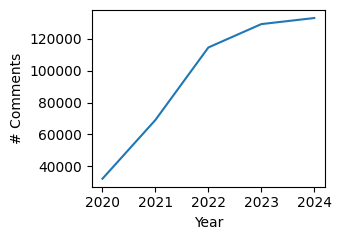

In [8]:
plt.figure(figsize=(3.5, 2.5))
sns.lineplot(data=df_temporal, x='periodo', y='total_comentarios')
plt.ylabel('# Comments')
plt.xlabel('Year')
plt.tight_layout()
plt.savefig('figs/total_comments_per_year_line.pdf')
plt.show()

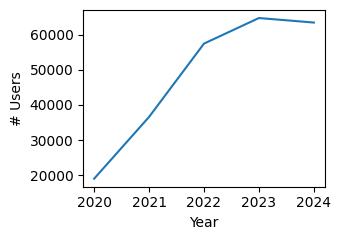

In [9]:
plt.figure(figsize=(3.5, 2.5))
sns.lineplot(data=df_temporal, x='periodo', y='total_usuarios')
plt.ylabel('# Users')
plt.xlabel('Year')
plt.tight_layout()
plt.savefig('figs/total_users_per_year_line.pdf')
plt.show()

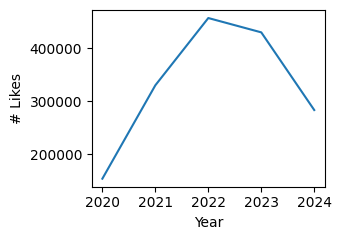

In [10]:
plt.figure(figsize=(3.5, 2.5))
sns.lineplot(data=df_temporal, x='periodo', y='total_likes')
plt.ylabel('# Likes')
plt.xlabel('Year')
plt.tight_layout()
plt.savefig('figs/total_likes_comment_per_year_line.pdf')
plt.show()

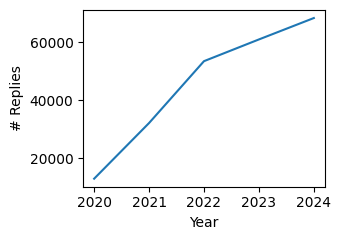

In [11]:
plt.figure(figsize=(3.5, 2.5))
sns.lineplot(data=df_temporal, x='periodo', y='total_replies')
plt.ylabel('# Replies')
plt.xlabel('Year')
plt.tight_layout()
plt.savefig('figs/total_replies_per_year_line.pdf')
plt.show()

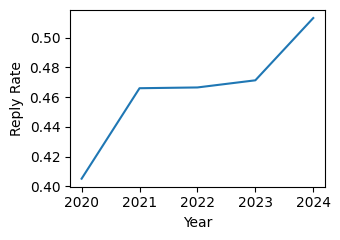

In [12]:
plt.figure(figsize=(3.5, 2.5))
sns.lineplot(data=df_temporal, x='periodo', y='reply_rate')
plt.ylabel('Reply Rate')
plt.xlabel('Year')
plt.tight_layout()
plt.savefig('figs/reply_rate_per_year_line.pdf')
plt.show()

---
## 3. Análise de Distribuições

Calcula métricas agregadas para entender padrões de engajamento:
- **number_comments_videos**: Comentários por vídeo (popularidade do vídeo)
- **number_comments_channels**: Comentários por canal (alcance do canal)
- **number_comments_users**: Comentários por usuário (nível de participação)
- **number_videos_users**: Vídeos por canal (produtividade do criador)
- **comment_length**: Comprimento dos comentários em caracteres

Visualizações ECDF (Empirical Cumulative Distribution Function) mostram:
- Distribuição de engajamento (a maioria dos vídeos/canais tem poucos comentários?)
- Padrões de participação dos usuários (muitos usuários casuais vs. poucos usuários frequentes?)
- Complexidade dos comentários (comentários longos e elaborados vs. curtos e diretos?)

Escala logarítmica usada em gráficos com alta variabilidade para melhor visualização de distribuições heavy-tailed.

In [13]:
df['number_comments_videos'] = df.groupby('video_id')['comment_id'].transform('count') # Número de comentários por vídeo
df['number_comments_channels'] = df.groupby('channel_id')['comment_id'].transform('count') # Número de comentários por canal
df['number_comments_users'] = df.groupby('author_channel_id')['comment_id'].transform('count') # Número de comentários por usuário
df['number_videos_channels'] = df.groupby('channel_id')['video_id'].transform('nunique') # Número de vídeos por canal
df['comment_length'] = df['comment'].apply(len) # Comprimento do comentário

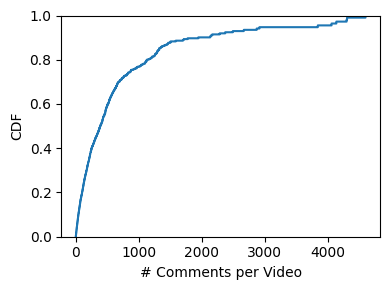

In [14]:
plt.figure(figsize=(4, 3))
sns.ecdfplot(data=df, x='number_comments_videos')
plt.xlabel('# Comments per Video')
plt.ylabel('CDF')
plt.tight_layout()
plt.savefig('figs/number_comments_videos.png')
plt.show()

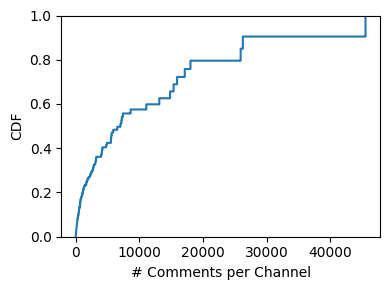

In [15]:
plt.figure(figsize=(4, 3))
sns.ecdfplot(data=df, x='number_comments_channels')
plt.xlabel('# Comments per Channel')
plt.ylabel('CDF')
plt.tight_layout()
plt.savefig('figs/number_comments_channels.png')
plt.show()

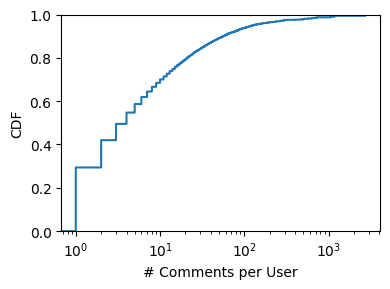

In [16]:
plt.figure(figsize=(4, 3))
sns.ecdfplot(data=df, x='number_comments_users')
plt.xlabel('# Comments per User')
plt.xscale('log')
plt.ylabel('CDF')
plt.tight_layout()
plt.savefig('figs/number_comments_users.png')
plt.show()

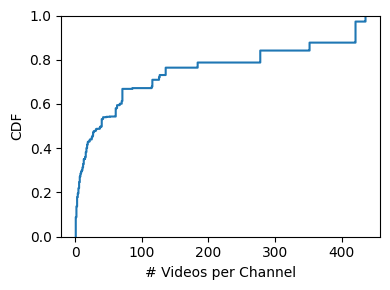

In [17]:
plt.figure(figsize=(4, 3))
sns.ecdfplot(data=df, x='number_videos_channels')
plt.xlabel('# Videos per Channel')
plt.ylabel('CDF')
plt.tight_layout()
plt.savefig('figs/number_videos_channels.png')
plt.show()

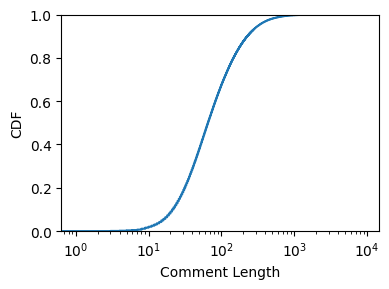

In [18]:
plt.figure(figsize=(4, 3))
sns.ecdfplot(data=df, x='comment_length')
plt.xlabel('Comment Length')
plt.xscale('log')
plt.ylabel('CDF')
plt.tight_layout()
plt.savefig('figs/comment_length.png')
plt.show()

---
## 4. Análise Temporal de Vídeos e Canais

Agrupa dados por **ano de publicação do vídeo** para analisar o crescimento da produção de conteúdo:
- **Vídeos**: Número único de vídeos publicados por ano
- **Canais**: Número de canais distintos que publicaram vídeos por ano

A data usada é o `published_at` do vídeo em `filtered_videos.csv` (YouTube Data API), que representa quando o conteúdo foi criado.

`view_count` e `like_count` em `filtered_videos.csv` são valores **cumulativos (snapshot)** coletados em um único momento — não representam o que aconteceu em cada ano. Vídeos mais antigos acumularam mais views/likes simplesmente por terem sido publicados há mais tempo. Por isso, a comparação por **média por vídeo** é mais adequada do que o total absoluto.

In [19]:
df_videos = pd.read_csv('cleaned_data/filtered_videos.csv')
valid_ids = df['video_id'].tolist()
df_valid_videos = df_videos[df_videos['video_id'].isin(valid_ids)].copy()

df_valid_videos.shape

(6104, 35)

In [20]:
df_valid_videos.head()

,video_id,title,description,channel_id,published_at,category_id,tags,view_count,like_count,comment_count,...,scheduled_end_time,concurrent_viewers,active_live_chat_id,recording_date,topicCategories,processing_status,parts_total,parts_processed,time_left_ms,processing_failure_reason
0,g3YDGLa2pWg,1 DURATESTON por semana: Dá para FICAR GRANDE?,1 DURATESTON por semana: Dá para FICAR GRANDE?...,UCYgV9EbxVSNdDHBr0GWLCmQ,2024-12-31,27,"['1 durateston por semana', '1 dura por semana...",6890,684,99,...,NaN,0,NaN,NaN,"['https://en.wikipedia.org/wiki/Health', 'http...",NaN,0,0,0,NaN
1,BMIQPwdZvN0,1ml DURATESTON por semana e REPOSIÇÃO ou CICLO...,De fã para fã,UCbzPEdQRN97S-VvDGXWwh4Q,2024-12-27,22,"['academia', 'musculação', 'fitness']",2436,164,11,...,NaN,0,NaN,NaN,['https://en.wikipedia.org/wiki/Lifestyle_(soc...,NaN,0,0,0,NaN
2,yvzlKwX8IFI,FERRITINA BAIXA COM DURATESTON: ISSO É NORMAL?,"Neste vídeo, respondo a uma dúvida intrigante ...",UCu18IKKSh83CIYzKilUCtUA,2024-12-08,27,"['Jorge Yamamoto', 'Dr Jorge Yamamoto', 'Testo...",1366,169,7,...,NaN,0,NaN,NaN,['https://en.wikipedia.org/wiki/Health'],NaN,0,0,0,NaN
4,grb8otb7UpA,A melhor forma de dividir a dose de testostero...,A melhor forma de dividir a dose de testostero...,UCYgV9EbxVSNdDHBr0GWLCmQ,2024-12-03,27,"['Melhor forma de fracionar a testosterona', '...",4183,464,72,...,NaN,0,NaN,NaN,"['https://en.wikipedia.org/wiki/Health', 'http...",NaN,0,0,0,NaN
5,UY9wG7vcBpk,ASHWAGANDHA substitui DURATESTON?,Será que a ashwagandha tem potencial de substi...,UC9cz05xObaFpB8U72t73IFA,2024-12-18,17,"['Fabrica de Monstros', 'FDM', 'Fabrica', 'Leo...",10346,866,3,...,NaN,0,NaN,NaN,['https://en.wikipedia.org/wiki/Health'],NaN,0,0,0,NaN


In [21]:
df_valid_videos['periodo'] = pd.to_datetime(df_valid_videos['published_at']).dt.to_period('Y')
df_videos_temporal = df_valid_videos.groupby('periodo').agg({
    'video_id': 'nunique',      # Número único de vídeos
    'channel_id': 'nunique',    # Número único de canais
    'view_count': 'sum',        # Número total de views
    'like_count': 'sum'         # Número total de likes
}).reset_index()

df_videos_temporal['periodo'] = df_videos_temporal['periodo'].astype(str)
df_videos_temporal.columns = ['periodo', 'total_videos', 'total_channels', 'total_views', 'total_likes']

df_videos_temporal.head()

,periodo,total_videos,total_channels,total_views,total_likes
0,2020,521,301,20046370,1350426
1,2021,911,365,60166946,3597418
2,2022,1405,343,97345180,6188840
3,2023,1643,425,59069419,3561450
4,2024,1624,364,26183136,1766769


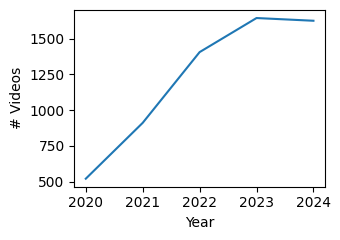

In [22]:
plt.figure(figsize=(3.5, 2.5))
sns.lineplot(data=df_videos_temporal, x='periodo', y='total_videos')
plt.ylabel('# Videos')
plt.xlabel('Year')
plt.tight_layout()
plt.savefig('figs/total_videos_per_year_line.pdf')
plt.show()

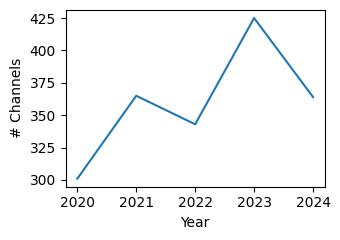

In [23]:
plt.figure(figsize=(3.5, 2.5))
sns.lineplot(data=df_videos_temporal, x='periodo', y='total_channels')
plt.ylabel('# Channels')
plt.xlabel('Year')
plt.tight_layout()
plt.savefig('figs/total_channels_per_year_line.pdf')
plt.show()

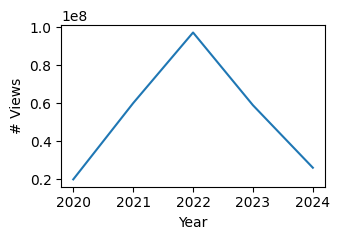

In [24]:
plt.figure(figsize=(3.5, 2.5))
sns.lineplot(data=df_videos_temporal, x='periodo', y='total_views')
plt.ylabel('# Views')
plt.xlabel('Year')
plt.yscale('linear')
plt.tight_layout()
# plt.savefig('figs/total_views_per_year_line.pdf')
plt.show()

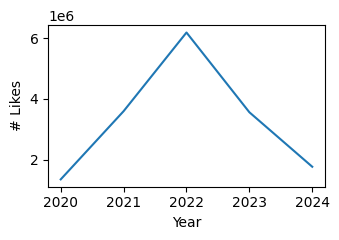

In [25]:
plt.figure(figsize=(3.5, 2.5))
sns.lineplot(data=df_videos_temporal, x='periodo', y='total_likes')
plt.ylabel('# Likes')
plt.xlabel('Year')
plt.yscale('linear')
plt.tight_layout()
plt.savefig('figs/total_likes_per_year_line.pdf')
plt.show()